**Output Quality: Semantic Similarity to No-Ad Baseline**

In [18]:
import json, re
import numpy as np
from pathlib import Path
from sentence_transformers import SentenceTransformer, util
import matplotlib.pyplot as plt
model = SentenceTransformer('multi-qa-MiniLM-L6-cos-v1')



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [19]:
def relevance_to_original_output(original_output: list, outputs_with_ad: list):
    orig_embedding = model.encode(original_output)
    ads_embedding  = model.encode(outputs_with_ad)
    return (1 + util.dot_score(ads_embedding, orig_embedding).numpy()) / 2


def extract_outputs(path, text_key, is_multi=False):
    logs = json.loads(Path(path).read_text())
    M    = len(logs)
    if is_multi:
        full = [trial[0][text_key] for trial in logs]
        new_sent = [None, None, None]
        first_k  = [None, None, full]   # only k=3 valid
    else:
        # first_k[k] = text of the first k+1 sentences (round k's cumulative output)
        first_k  = [[trial[k][text_key] for trial in logs] for k in range(3)]
        # new_sent[t] = sentence added at round t (strip the previous cumulative prefix)
        new_sent = [first_k[0]]
        for t in range(1, 3):
            new_sent.append([
                trial[t][text_key][len(trial[t-1][text_key]):].strip()
                for trial in logs
            ])
    return new_sent, first_k, M

def extract_outputs_vcg(path, text_key):
    logs = json.loads(Path(path).read_text())
    M    = len(logs)
    full = [trial[text_key] for trial in logs]   # one output per trial
    new_sent = [None, None, None]
    first_k  = [None, None, full]                # only k=3 valid
    return new_sent, first_k, M

In [20]:
def mean_se(x):
    return np.mean(x), np.std(x)/np.sqrt(len(x))

# Senario 1

In [21]:
# ── No-ad baseline ────────────────────────────────────────────────────────────
payload       = json.loads(Path('No-Ad Response/generated_no_ad_outputs_scenario_1.json').read_text())
no_ad_outputs = payload['outputs']   # list of 10 full 3-sentence strings
N_noAd        = len(no_ad_outputs)
print(f'No-ad baseline: {N_noAd} samples')


SEG_KEYS = ['1st', '2nd', '3rd']
CUM_KEYS = ['k1',  'k2',  'k3' ]

def score_trials(ad_texts):
    return relevance_to_original_output(no_ad_outputs, ad_texts).mean(axis=1)


No-ad baseline: 10 samples


In [22]:
METHODS = [
    ('Seg w/ repl.',  'Seg single & multi/Seg_single_with_replacement_logs_scenario_1.json',                                'generated_text', False),
    ('Seg w/o repl.', 'Seg single & multi/Seg_single_without_replacement_logs_scenario_1.json',                             'generated_text', False),
    ('QP w/ repl.',  'QP single/QP_single_with_replacement_logs_scenario_1.json',                  'output',         False),
    ('QP w/o repl.', 'QP single/QP_single_without_replacement_logs_scenario_1.json',               'output',         False),
    ('Seg multi-alloc',   'Seg single & multi/Seg_multi_logs_scenario_1.json',                               'generated_text', True ),
]


all_outputs = {}
for label, path, key, is_multi in METHODS:
    all_outputs[label] = extract_outputs(path, key, is_multi)
    print(f'Loaded: {label}  (M={all_outputs[label][2]} trials)')



vcg_label = 'QP multi-alloc'
vcg_path  = "QP multi/QP_multi_logs_scenario_1.json"
all_outputs[vcg_label] = extract_outputs_vcg(vcg_path, 'output')
print(f'Loaded: {vcg_label}  (M={all_outputs[vcg_label][2]} trials)')

results = {}
for label, (new_sent, first_k, M) in all_outputs.items():
    row = {}
    for t, k in enumerate(SEG_KEYS):
        row[k] = mean_se(score_trials(new_sent[t])) if new_sent[t] is not None else None
    for k_idx, k in enumerate(CUM_KEYS):
        row[k] = mean_se(score_trials(first_k[k_idx])) if first_k[k_idx] is not None else None
    results[label] = row
    print(f'  {label}: done')


new_sent_vcg, first_k_vcg, M_vcg = all_outputs[vcg_label]
row_vcg = {}
for t, k in enumerate(SEG_KEYS):
    row_vcg[k] = mean_se(score_trials(new_sent_vcg[t])) if new_sent_vcg[t] is not None else None
for k_idx, k in enumerate(CUM_KEYS):
    row_vcg[k] = mean_se(score_trials(first_k_vcg[k_idx])) if first_k_vcg[k_idx] is not None else None
results[vcg_label] = row_vcg

Loaded: Seg w/ repl.  (M=100 trials)
Loaded: Seg w/o repl.  (M=100 trials)
Loaded: QP w/ repl.  (M=100 trials)
Loaded: QP w/o repl.  (M=100 trials)
Loaded: Seg multi-alloc  (M=100 trials)
Loaded: QP multi-alloc  (M=100 trials)
  Seg w/ repl.: done
  Seg w/o repl.: done
  QP w/ repl.: done
  QP w/o repl.: done
  Seg multi-alloc: done
  QP multi-alloc: done


In [23]:
# ── Print table ───────────────────────────────────────────────────────────────

def fmt(v, se): return f'{v:.2f} (\u00b1.{int(round(se*1000)):03d})'
DASH = '       —        '

HEADERS = ['Mechanism', '1st seg', '2nd seg', '3rd seg', 'k=1', 'k=2', 'k=3']
COL_W   = [16] + [18]*6

print('\n' + '='*120)
print('  '.join(h.ljust(w) for h, w in zip(HEADERS, COL_W)))
print('-'*120)
for label, row in results.items():
    seg_vals = [DASH if row[k] is None else fmt(*row[k]) for k in SEG_KEYS]
    cum_vals = [DASH if row[k] is None else fmt(*row[k]) for k in CUM_KEYS]
    cells    = [label] + seg_vals + cum_vals
    print('  '.join(str(c).ljust(w) for c, w in zip(cells, COL_W)))
print('='*120)



Mechanism         1st seg             2nd seg             3rd seg             k=1                 k=2                 k=3               
------------------------------------------------------------------------------------------------------------------------
Seg w/ repl.      0.77 (±.007)        0.67 (±.008)        0.66 (±.009)        0.77 (±.007)        0.75 (±.006)        0.73 (±.005)      
Seg w/o repl.     0.78 (±.008)        0.68 (±.008)        0.68 (±.007)        0.78 (±.008)        0.76 (±.007)        0.75 (±.005)      
QP w/ repl.       0.83 (±.006)        0.72 (±.009)        0.72 (±.010)        0.83 (±.006)        0.82 (±.007)        0.81 (±.007)      
QP w/o repl.      0.84 (±.006)        0.73 (±.008)        0.77 (±.008)        0.84 (±.006)        0.84 (±.005)        0.85 (±.004)      
Seg multi-alloc          —                   —                   —                   —                   —            0.77 (±.005)      
QP multi-alloc           —                   —          

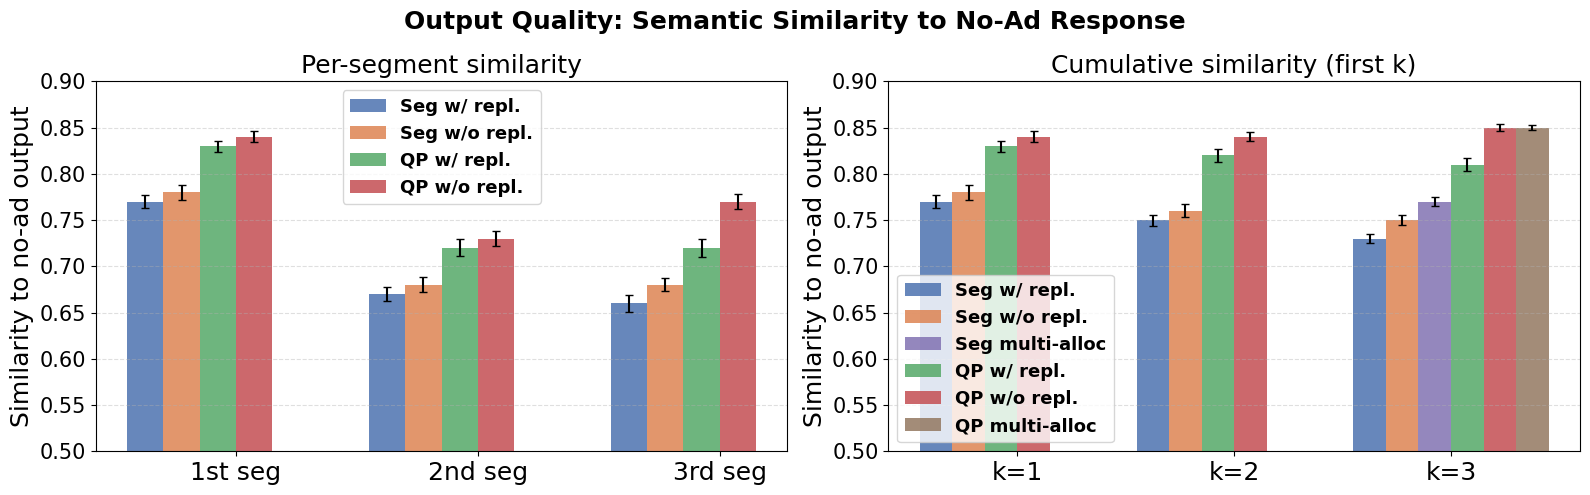

In [24]:

# ── Bar chart ─────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']
COLOR_MAP = {label: color for label, color in zip(results, COLORS)}

bar_w = 0.15
n_m   = len(results)


K3_ORDER = ['Seg w/ repl.', 'Seg w/o repl.', 'Seg multi-alloc', 'QP w/ repl.','QP w/o repl.', 'QP multi-alloc' ]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))


plt.rcParams.update({
    'font.weight': 'normal',
    'axes.titleweight': 'normal',
    'axes.labelweight': 'normal',
})

# ── Left: per-segment ────────────────────────────────────────
ax = axes[0]
x = np.arange(len(SEG_KEYS))
for m_idx, (label, color) in enumerate(zip(results, COLORS)):
    means  = [round(results[label][k][0], 2) if results[label][k] is not None else 0 for k in SEG_KEYS]
    errors = [round(results[label][k][1], 3) if results[label][k] is not None else 0 for k in SEG_KEYS]
    valid  = [results[label][k] is not None for k in SEG_KEYS]
    bar_means  = [m if v else np.nan for m, v in zip(means,  valid)]
    bar_errors = [e if v else np.nan for e, v in zip(errors, valid)]
    ax.bar(x + (m_idx - n_m/2 + 0.5)*bar_w, bar_means, bar_w,
           yerr=bar_errors,
           label=label if label not in ('Seg multi-alloc', 'QP multi-alloc') else '_nolegend_',
           color=color, capsize=3, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(['1st seg', '2nd seg', '3rd seg'], fontsize=18)
ax.set_ylabel('Similarity to no-ad output', fontsize=18)
ax.set_title('Per-segment similarity', fontsize=18)
ax.set_ylim(0.5, 0.9)
ax.tick_params(axis='y', labelsize=15)
ax.grid(axis='y', linestyle='--', alpha=0.4)

handles, labels = ax.get_legend_handles_labels()
leg = ax.legend(handles[:4], labels[:4], fontsize=13, loc='upper center')
for text in leg.get_texts():
    text.set_fontweight('bold')


# ── Right: cumulative ───────────────────────────────────
ax = axes[1]
x = np.arange(len(CUM_KEYS))
for m_idx, label in enumerate(K3_ORDER):
    color = COLOR_MAP[label]
    bar_means  = []
    bar_errors = []
    for k_idx, k in enumerate(CUM_KEYS):
        val = results[label][k]
        if k == 'k3':
            pos = m_idx
        else:
            pos = list(results.keys()).index(label)
        if val is not None:
            bar_means.append(val[0])
            bar_errors.append(val[1])
        else:
            bar_means.append(np.nan)
            bar_errors.append(np.nan)
    for k_idx, k in enumerate(CUM_KEYS):
        val = results[label][k]
        if k == 'k3':
            pos = m_idx
        else:
            pos = list(results.keys()).index(label)
        mean_val  = round(val[0], 2) if val is not None else np.nan
        error_val = round(val[1], 3) if val is not None else np.nan
        ax.bar(k_idx + (pos - n_m/2 + 0.5)*bar_w, mean_val, bar_w,
               yerr=error_val if not np.isnan(mean_val) else 0,
               color=color, capsize=3, alpha=0.85,
               label=label if k_idx == 0 else '_nolegend_')

ax.set_xticks(x); ax.set_xticklabels(['k=1', 'k=2', 'k=3'], fontsize=18)
ax.tick_params(axis='y', labelsize=15)
ax.set_ylabel('Similarity to no-ad output', fontsize=18)
ax.set_title('Cumulative similarity (first k)', fontsize=18)
ax.set_ylim(0.5, 0.9)
ax.grid(axis='y', linestyle='--', alpha=0.4)

leg = ax.legend(fontsize=13)
for text in leg.get_texts():
    text.set_fontweight('bold')


plt.suptitle('Output Quality: Semantic Similarity to No-Ad Response', fontsize=18, fontweight='bold')
plt.tight_layout()
#plt.savefig('output_quality_similarity.pdf', bbox_inches='tight', dpi=150)
plt.show()

# Senario 2

In [25]:
# ── No-ad baseline ────────────────────────────────────────────────────────────
payload       = json.loads(Path('No-Ad Response/generated_no_ad_outputs_scenario_2-4.json').read_text())
no_ad_outputs = payload['outputs']   # list of 10 full 3-sentence strings
N_noAd        = len(no_ad_outputs)
print(f'No-ad baseline: {N_noAd} samples')


SEG_KEYS = ['1st', '2nd', '3rd']
CUM_KEYS = ['k1',  'k2',  'k3' ]

def score_trials(ad_texts):
    return relevance_to_original_output(no_ad_outputs, ad_texts).mean(axis=1)


No-ad baseline: 10 samples


In [26]:
METHODS = [
    ('Seg w/ repl.',  'Seg single & multi/Seg_single_with_replacement_logs_scenario_2.json',                                'generated_text', False),
    ('Seg w/o repl.', 'Seg single & multi/Seg_single_without_replacement_logs_scenario_2.json',                             'generated_text', False),
    ('QP w/ repl.',  'QP single/QP_single_with_replacement_logs_scenario_2.json',                  'output',         False),
    ('QP w/o repl.', 'QP single/QP_single_without_replacement_logs_scenario_2.json',               'output',         False),
    ('Seg multi-alloc',   'Seg single & multi/Seg_multi_logs_scenario_2.json',                               'generated_text', True ),
]


all_outputs = {}
for label, path, key, is_multi in METHODS:
    all_outputs[label] = extract_outputs(path, key, is_multi)
    print(f'Loaded: {label}  (M={all_outputs[label][2]} trials)')



vcg_label = 'QP multi-alloc'
vcg_path  = "QP multi/QP_multi_logs_scenario_2.json"
all_outputs[vcg_label] = extract_outputs_vcg(vcg_path, 'output')
print(f'Loaded: {vcg_label}  (M={all_outputs[vcg_label][2]} trials)')

results = {}
for label, (new_sent, first_k, M) in all_outputs.items():
    row = {}
    for t, k in enumerate(SEG_KEYS):
        row[k] = mean_se(score_trials(new_sent[t])) if new_sent[t] is not None else None
    for k_idx, k in enumerate(CUM_KEYS):
        row[k] = mean_se(score_trials(first_k[k_idx])) if first_k[k_idx] is not None else None
    results[label] = row
    print(f'  {label}: done')


new_sent_vcg, first_k_vcg, M_vcg = all_outputs[vcg_label]
row_vcg = {}
for t, k in enumerate(SEG_KEYS):
    row_vcg[k] = mean_se(score_trials(new_sent_vcg[t])) if new_sent_vcg[t] is not None else None
for k_idx, k in enumerate(CUM_KEYS):
    row_vcg[k] = mean_se(score_trials(first_k_vcg[k_idx])) if first_k_vcg[k_idx] is not None else None
results[vcg_label] = row_vcg

Loaded: Seg w/ repl.  (M=100 trials)
Loaded: Seg w/o repl.  (M=100 trials)
Loaded: QP w/ repl.  (M=100 trials)
Loaded: QP w/o repl.  (M=100 trials)
Loaded: Seg multi-alloc  (M=100 trials)
Loaded: QP multi-alloc  (M=100 trials)
  Seg w/ repl.: done
  Seg w/o repl.: done
  QP w/ repl.: done
  QP w/o repl.: done
  Seg multi-alloc: done
  QP multi-alloc: done


In [27]:
# ── Print table ───────────────────────────────────────────────────────────────
def fmt(v, se): return f'{v:.2f} (\u00b1.{int(round(se*1000)):03d})'
DASH = '       —        '

HEADERS = ['Mechanism', '1st seg', '2nd seg', '3rd seg', 'k=1', 'k=2', 'k=3']
COL_W   = [16] + [18]*6

print('\n' + '='*120)
print('  '.join(h.ljust(w) for h, w in zip(HEADERS, COL_W)))
print('-'*120)
for label, row in results.items():
    seg_vals = [DASH if row[k] is None else fmt(*row[k]) for k in SEG_KEYS]
    cum_vals = [DASH if row[k] is None else fmt(*row[k]) for k in CUM_KEYS]
    cells    = [label] + seg_vals + cum_vals
    print('  '.join(str(c).ljust(w) for c, w in zip(cells, COL_W)))
print('='*120)



Mechanism         1st seg             2nd seg             3rd seg             k=1                 k=2                 k=3               
------------------------------------------------------------------------------------------------------------------------
Seg w/ repl.      0.77 (±.005)        0.60 (±.005)        0.59 (±.005)        0.77 (±.005)        0.74 (±.004)        0.73 (±.004)      
Seg w/o repl.     0.77 (±.005)        0.60 (±.005)        0.59 (±.006)        0.77 (±.005)        0.74 (±.005)        0.74 (±.004)      
QP w/ repl.       0.80 (±.003)        0.67 (±.007)        0.67 (±.008)        0.80 (±.003)        0.80 (±.004)        0.80 (±.004)      
QP w/o repl.      0.80 (±.003)        0.69 (±.008)        0.73 (±.007)        0.80 (±.003)        0.81 (±.004)        0.83 (±.003)      
Seg multi-alloc          —                   —                   —                   —                   —            0.78 (±.003)      
QP multi-alloc           —                   —          

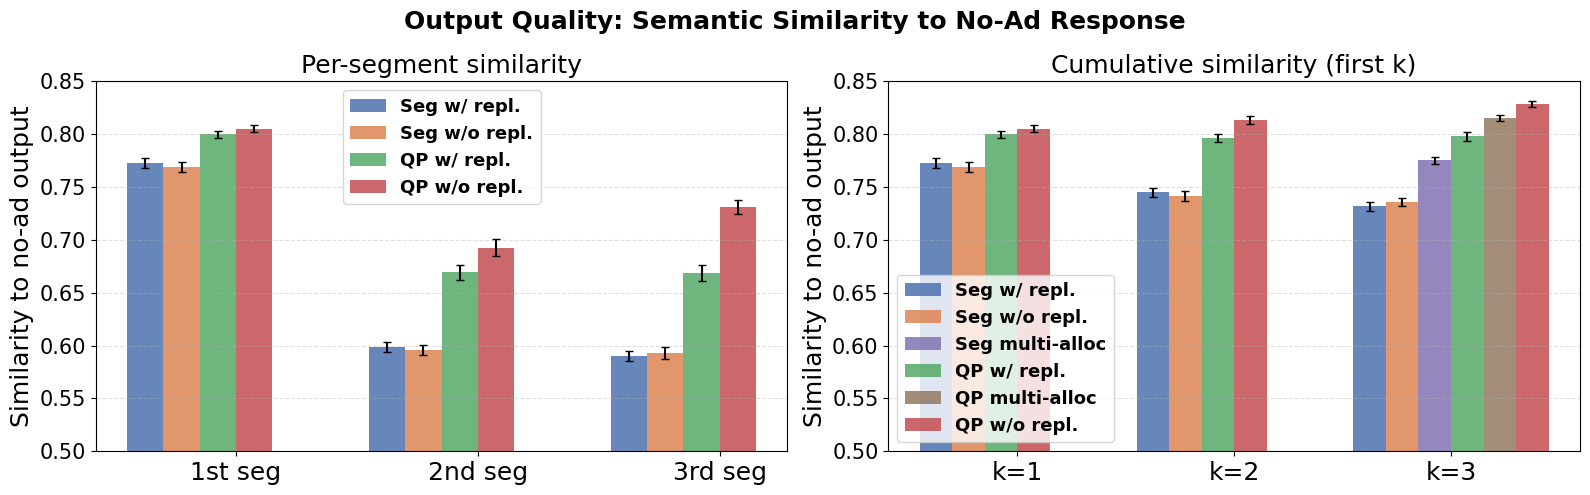

In [28]:

# ── Bar chart ─────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']
COLOR_MAP = {label: color for label, color in zip(results, COLORS)}

bar_w = 0.15
n_m   = len(results)

K3_ORDER = ['Seg w/ repl.', 'Seg w/o repl.', 'Seg multi-alloc', 'QP w/ repl.', 'QP multi-alloc','QP w/o repl.']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))


plt.rcParams.update({
    'font.weight': 'normal',
    'axes.titleweight': 'normal',
    'axes.labelweight': 'normal',
})

# ── Left: per-segment ────────────────────────────────────────
ax = axes[0]
x = np.arange(len(SEG_KEYS))
for m_idx, (label, color) in enumerate(zip(results, COLORS)):
    means  = [results[label][k][0] if results[label][k] is not None else 0 for k in SEG_KEYS]
    errors = [results[label][k][1] if results[label][k] is not None else 0 for k in SEG_KEYS]
    valid  = [results[label][k] is not None for k in SEG_KEYS]
    bar_means  = [m if v else np.nan for m, v in zip(means,  valid)]
    bar_errors = [e if v else np.nan for e, v in zip(errors, valid)]
    ax.bar(x + (m_idx - n_m/2 + 0.5)*bar_w, bar_means, bar_w,
           yerr=bar_errors,
           label=label if label not in ('Seg multi-alloc', 'QP multi-alloc') else '_nolegend_',
           color=color, capsize=3, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(['1st seg', '2nd seg', '3rd seg'], fontsize=18)
ax.set_ylabel('Similarity to no-ad output', fontsize=18)
ax.set_title('Per-segment similarity', fontsize=18)
ax.set_ylim(0.5, 0.85)
ax.tick_params(axis='y', labelsize=15)
ax.grid(axis='y', linestyle='--', alpha=0.4)

leg = ax.legend(fontsize=13, loc='upper center')
for text in leg.get_texts():
    text.set_fontweight('bold')


# ── Right: cumulative ───────────────────────────────────
ax = axes[1]
x = np.arange(len(CUM_KEYS))
for m_idx, label in enumerate(K3_ORDER):
    color = COLOR_MAP[label]
    bar_means  = []
    bar_errors = []
    for k_idx, k in enumerate(CUM_KEYS):
        val = results[label][k]
        if k == 'k3':
            pos = m_idx
        else:
            pos = list(results.keys()).index(label)
        if val is not None:
            bar_means.append(val[0])
            bar_errors.append(val[1])
        else:
            bar_means.append(np.nan)
            bar_errors.append(np.nan)
    for k_idx, k in enumerate(CUM_KEYS):
        val = results[label][k]
        if k == 'k3':
            pos = m_idx
        else:
            pos = list(results.keys()).index(label)
        mean_val  = val[0] if val is not None else np.nan
        error_val = val[1] if val is not None else np.nan
        ax.bar(k_idx + (pos - n_m/2 + 0.5)*bar_w, mean_val, bar_w,
               yerr=error_val if not np.isnan(mean_val) else 0,
               color=color, capsize=3, alpha=0.85,
               label=label if k_idx == 0 else '_nolegend_')

ax.set_xticks(x); ax.set_xticklabels(['k=1', 'k=2', 'k=3'], fontsize=18)
ax.tick_params(axis='y', labelsize=15)
ax.set_ylabel('Similarity to no-ad output', fontsize=18)
ax.set_title('Cumulative similarity (first k)', fontsize=18)
ax.set_ylim(0.5, 0.85)
ax.grid(axis='y', linestyle='--', alpha=0.4)

leg = ax.legend(fontsize=13)
for text in leg.get_texts():
    text.set_fontweight('bold')

plt.suptitle('Output Quality: Semantic Similarity to No-Ad Response', fontsize=18, fontweight='bold')
plt.tight_layout()
#plt.savefig('output_quality_similarity.pdf', bbox_inches='tight', dpi=150)
plt.show()

# Senario 3

In [29]:
# ── No-ad baseline ────────────────────────────────────────────────────────────
payload       = json.loads(Path('No-Ad Response/generated_no_ad_outputs_scenario_2-4.json').read_text())
no_ad_outputs = payload['outputs']   # list of 10 full 3-sentence strings
N_noAd        = len(no_ad_outputs)
print(f'No-ad baseline: {N_noAd} samples')


SEG_KEYS = ['1st', '2nd', '3rd']
CUM_KEYS = ['k1',  'k2',  'k3' ]

def score_trials(ad_texts):
    return relevance_to_original_output(no_ad_outputs, ad_texts).mean(axis=1)


No-ad baseline: 10 samples


In [30]:
METHODS = [
    ('Seg w/ repl.',  'Seg single & multi/Seg_single_with_replacement_logs_scenario_3.json',                                'generated_text', False),
    ('Seg w/o repl.', 'Seg single & multi/Seg_single_without_replacement_logs_scenario_3.json',                             'generated_text', False),
    ('QP w/ repl.',  'QP single/QP_single_with_replacement_logs_scenario_3.json',                  'output',         False),
    ('QP w/o repl.', 'QP single/QP_single_without_replacement_logs_scenario_3.json',               'output',         False),
    ('Seg multi-alloc',   'Seg single & multi/Seg_multi_logs_scenario_3.json',                               'generated_text', True ),
]


all_outputs = {}
for label, path, key, is_multi in METHODS:
    all_outputs[label] = extract_outputs(path, key, is_multi)
    print(f'Loaded: {label}  (M={all_outputs[label][2]} trials)')



vcg_label = 'QP multi-alloc'
vcg_path  = "QP multi/QP_multi_logs_scenario_3.json"
all_outputs[vcg_label] = extract_outputs_vcg(vcg_path, 'output')
print(f'Loaded: {vcg_label}  (M={all_outputs[vcg_label][2]} trials)')

results = {}
for label, (new_sent, first_k, M) in all_outputs.items():
    row = {}
    for t, k in enumerate(SEG_KEYS):
        row[k] = mean_se(score_trials(new_sent[t])) if new_sent[t] is not None else None
    for k_idx, k in enumerate(CUM_KEYS):
        row[k] = mean_se(score_trials(first_k[k_idx])) if first_k[k_idx] is not None else None
    results[label] = row
    print(f'  {label}: done')


new_sent_vcg, first_k_vcg, M_vcg = all_outputs[vcg_label]
row_vcg = {}
for t, k in enumerate(SEG_KEYS):
    row_vcg[k] = mean_se(score_trials(new_sent_vcg[t])) if new_sent_vcg[t] is not None else None
for k_idx, k in enumerate(CUM_KEYS):
    row_vcg[k] = mean_se(score_trials(first_k_vcg[k_idx])) if first_k_vcg[k_idx] is not None else None
results[vcg_label] = row_vcg

Loaded: Seg w/ repl.  (M=100 trials)
Loaded: Seg w/o repl.  (M=100 trials)
Loaded: QP w/ repl.  (M=100 trials)
Loaded: QP w/o repl.  (M=100 trials)
Loaded: Seg multi-alloc  (M=100 trials)
Loaded: QP multi-alloc  (M=100 trials)
  Seg w/ repl.: done
  Seg w/o repl.: done
  QP w/ repl.: done
  QP w/o repl.: done
  Seg multi-alloc: done
  QP multi-alloc: done


In [31]:
# ── Print table ───────────────────────────────────────────────────────────────

def fmt(v, se): return f'{v:.2f} (\u00b1.{int(round(se*1000)):03d})'
DASH = '       —        '

HEADERS = ['Mechanism', '1st seg', '2nd seg', '3rd seg', 'k=1', 'k=2', 'k=3']
COL_W   = [16] + [18]*6

print('\n' + '='*120)
print('  '.join(h.ljust(w) for h, w in zip(HEADERS, COL_W)))
print('-'*120)
for label, row in results.items():
    seg_vals = [DASH if row[k] is None else fmt(*row[k]) for k in SEG_KEYS]
    cum_vals = [DASH if row[k] is None else fmt(*row[k]) for k in CUM_KEYS]
    cells    = [label] + seg_vals + cum_vals
    print('  '.join(str(c).ljust(w) for c, w in zip(cells, COL_W)))
print('='*120)



Mechanism         1st seg             2nd seg             3rd seg             k=1                 k=2                 k=3               
------------------------------------------------------------------------------------------------------------------------
Seg w/ repl.      0.76 (±.005)        0.57 (±.004)        0.56 (±.005)        0.76 (±.005)        0.72 (±.005)        0.71 (±.004)      
Seg w/o repl.     0.76 (±.005)        0.59 (±.005)        0.59 (±.005)        0.76 (±.005)        0.73 (±.005)        0.72 (±.005)      
QP w/ repl.       0.77 (±.006)        0.63 (±.009)        0.62 (±.009)        0.77 (±.006)        0.75 (±.007)        0.75 (±.007)      
QP w/o repl.      0.76 (±.006)        0.65 (±.009)        0.67 (±.009)        0.76 (±.006)        0.75 (±.007)        0.78 (±.006)      
Seg multi-alloc          —                   —                   —                   —                   —            0.78 (±.003)      
QP multi-alloc           —                   —          

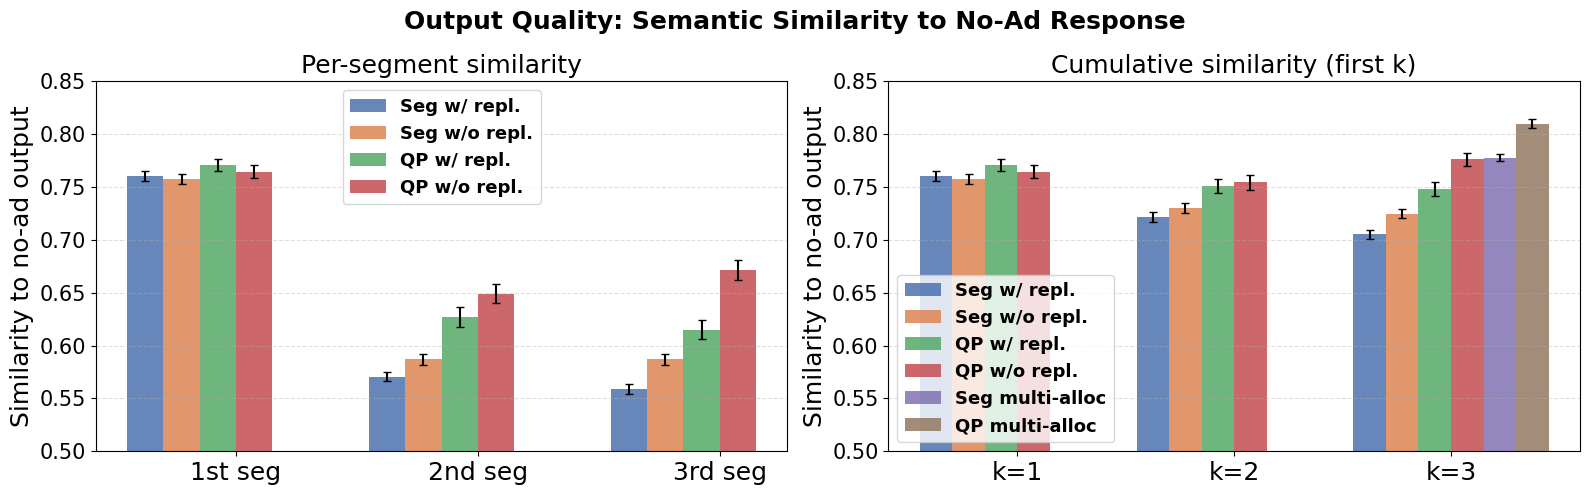

In [32]:
# ── Bar chart ─────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']
COLOR_MAP = {label: color for label, color in zip(results, COLORS)}

bar_w = 0.15
n_m   = len(results)


K3_ORDER = ['Seg w/ repl.', 'Seg w/o repl.',  'QP w/ repl.','QP w/o repl.', 'Seg multi-alloc', 'QP multi-alloc'  ]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))


plt.rcParams.update({
    'font.weight': 'normal',
    'axes.titleweight': 'normal',
    'axes.labelweight': 'normal',
})

# ── Left: per-segment ────────────────────────────────────────
ax = axes[0]
x = np.arange(len(SEG_KEYS))
for m_idx, (label, color) in enumerate(zip(results, COLORS)):
    means  = [results[label][k][0] if results[label][k] is not None else 0 for k in SEG_KEYS]
    errors = [results[label][k][1] if results[label][k] is not None else 0 for k in SEG_KEYS]
    valid  = [results[label][k] is not None for k in SEG_KEYS]
    bar_means  = [m if v else np.nan for m, v in zip(means,  valid)]
    bar_errors = [e if v else np.nan for e, v in zip(errors, valid)]
    ax.bar(x + (m_idx - n_m/2 + 0.5)*bar_w, bar_means, bar_w,
           yerr=bar_errors,
           label=label if label not in ('Seg multi-alloc', 'QP multi-alloc') else '_nolegend_',
           color=color, capsize=3, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(['1st seg', '2nd seg', '3rd seg'], fontsize=18)
ax.set_ylabel('Similarity to no-ad output', fontsize=18)
ax.set_title('Per-segment similarity', fontsize=18)
ax.set_ylim(0.5, 0.85)
ax.tick_params(axis='y', labelsize=15)
ax.grid(axis='y', linestyle='--', alpha=0.4)

leg = ax.legend(fontsize=13, loc='upper center')
for text in leg.get_texts():
    text.set_fontweight('bold')


# ── Right: cumulative ───────────────────────────────────
ax = axes[1]
x = np.arange(len(CUM_KEYS))
for m_idx, label in enumerate(K3_ORDER):
    color = COLOR_MAP[label]
    bar_means  = []
    bar_errors = []
    for k_idx, k in enumerate(CUM_KEYS):
        val = results[label][k]
        if k == 'k3':
            pos = m_idx
        else:
            pos = list(results.keys()).index(label)
        if val is not None:
            bar_means.append(val[0])
            bar_errors.append(val[1])
        else:
            bar_means.append(np.nan)
            bar_errors.append(np.nan)
    for k_idx, k in enumerate(CUM_KEYS):
        val = results[label][k]
        if k == 'k3':
            pos = m_idx
        else:
            pos = list(results.keys()).index(label)
        mean_val  = val[0] if val is not None else np.nan
        error_val = val[1] if val is not None else np.nan
        ax.bar(k_idx + (pos - n_m/2 + 0.5)*bar_w, mean_val, bar_w,
               yerr=error_val if not np.isnan(mean_val) else 0,
               color=color, capsize=3, alpha=0.85,
               label=label if k_idx == 0 else '_nolegend_')

ax.set_xticks(x); ax.set_xticklabels(['k=1', 'k=2', 'k=3'], fontsize=18)
ax.tick_params(axis='y', labelsize=15)
ax.set_ylabel('Similarity to no-ad output', fontsize=18)
ax.set_title('Cumulative similarity (first k)', fontsize=18)
ax.set_ylim(0.5, 0.85)
ax.grid(axis='y', linestyle='--', alpha=0.4)

leg = ax.legend(fontsize=13)
for text in leg.get_texts():
    text.set_fontweight('bold')

plt.suptitle('Output Quality: Semantic Similarity to No-Ad Response', fontsize=18, fontweight='bold')
plt.tight_layout()
#plt.savefig('output_quality_similarity.pdf', bbox_inches='tight', dpi=150)
plt.show()

# Senario 4

In [33]:
# ── No-ad baseline ────────────────────────────────────────────────────────────
payload       = json.loads(Path('No-Ad Response/generated_no_ad_outputs_scenario_2-4.json').read_text())
no_ad_outputs = payload['outputs']   # list of 10 full 3-sentence strings
N_noAd        = len(no_ad_outputs)
print(f'No-ad baseline: {N_noAd} samples')


SEG_KEYS = ['1st', '2nd', '3rd']
CUM_KEYS = ['k1',  'k2',  'k3' ]

def score_trials(ad_texts):
    return relevance_to_original_output(no_ad_outputs, ad_texts).mean(axis=1)


No-ad baseline: 10 samples


In [34]:
METHODS = [
    ('Seg w/ repl.',  'Seg single & multi/Seg_single_with_replacement_logs_scenario_4.json',                                'generated_text', False),
    ('Seg w/o repl.', 'Seg single & multi/Seg_single_without_replacement_logs_scenario_4.json',                             'generated_text', False),
    ('QP w/ repl.',  'QP single/QP_single_with_replacement_logs_scenario_4.json',                  'output',         False),
    ('QP w/o repl.', 'QP single/QP_single_without_replacement_logs_scenario_4.json',               'output',         False),
    ('Seg multi-alloc',   'Seg single & multi/Seg_multi_logs_scenario_4.json',                               'generated_text', True ),
]


all_outputs = {}
for label, path, key, is_multi in METHODS:
    all_outputs[label] = extract_outputs(path, key, is_multi)
    print(f'Loaded: {label}  (M={all_outputs[label][2]} trials)')


vcg_label = 'QP multi-alloc'
vcg_path  = "QP multi/QP_multi_logs_scenario_4.json"
all_outputs[vcg_label] = extract_outputs_vcg(vcg_path, 'output')
print(f'Loaded: {vcg_label}  (M={all_outputs[vcg_label][2]} trials)')

results = {}
for label, (new_sent, first_k, M) in all_outputs.items():
    row = {}
    for t, k in enumerate(SEG_KEYS):
        row[k] = mean_se(score_trials(new_sent[t])) if new_sent[t] is not None else None
    for k_idx, k in enumerate(CUM_KEYS):
        row[k] = mean_se(score_trials(first_k[k_idx])) if first_k[k_idx] is not None else None
    results[label] = row
    print(f'  {label}: done')


new_sent_vcg, first_k_vcg, M_vcg = all_outputs[vcg_label]
row_vcg = {}
for t, k in enumerate(SEG_KEYS):
    row_vcg[k] = mean_se(score_trials(new_sent_vcg[t])) if new_sent_vcg[t] is not None else None
for k_idx, k in enumerate(CUM_KEYS):
    row_vcg[k] = mean_se(score_trials(first_k_vcg[k_idx])) if first_k_vcg[k_idx] is not None else None
results[vcg_label] = row_vcg

Loaded: Seg w/ repl.  (M=100 trials)
Loaded: Seg w/o repl.  (M=100 trials)
Loaded: QP w/ repl.  (M=100 trials)
Loaded: QP w/o repl.  (M=100 trials)
Loaded: Seg multi-alloc  (M=100 trials)
Loaded: QP multi-alloc  (M=100 trials)
  Seg w/ repl.: done
  Seg w/o repl.: done
  QP w/ repl.: done
  QP w/o repl.: done
  Seg multi-alloc: done
  QP multi-alloc: done


In [35]:
# ── Print table ───────────────────────────────────────────────────────────────

def fmt(v, se): return f'{v:.2f} (\u00b1.{int(round(se*1000)):03d})'
DASH = '       —        '

HEADERS = ['Mechanism', '1st seg', '2nd seg', '3rd seg', 'k=1', 'k=2', 'k=3']
COL_W   = [16] + [18]*6

print('\n' + '='*120)
print('  '.join(h.ljust(w) for h, w in zip(HEADERS, COL_W)))
print('-'*120)
for label, row in results.items():
    seg_vals = [DASH if row[k] is None else fmt(*row[k]) for k in SEG_KEYS]
    cum_vals = [DASH if row[k] is None else fmt(*row[k]) for k in CUM_KEYS]
    cells    = [label] + seg_vals + cum_vals
    print('  '.join(str(c).ljust(w) for c, w in zip(cells, COL_W)))
print('='*120)



Mechanism         1st seg             2nd seg             3rd seg             k=1                 k=2                 k=3               
------------------------------------------------------------------------------------------------------------------------
Seg w/ repl.      0.76 (±.006)        0.58 (±.005)        0.57 (±.005)        0.76 (±.006)        0.73 (±.005)        0.72 (±.005)      
Seg w/o repl.     0.76 (±.005)        0.58 (±.005)        0.57 (±.005)        0.76 (±.005)        0.74 (±.005)        0.73 (±.004)      
QP w/ repl.       0.80 (±.004)        0.68 (±.008)        0.65 (±.008)        0.80 (±.004)        0.80 (±.005)        0.79 (±.005)      
QP w/o repl.      0.80 (±.004)        0.67 (±.009)        0.66 (±.010)        0.80 (±.004)        0.79 (±.006)        0.79 (±.006)      
Seg multi-alloc          —                   —                   —                   —                   —            0.79 (±.003)      
QP multi-alloc           —                   —          

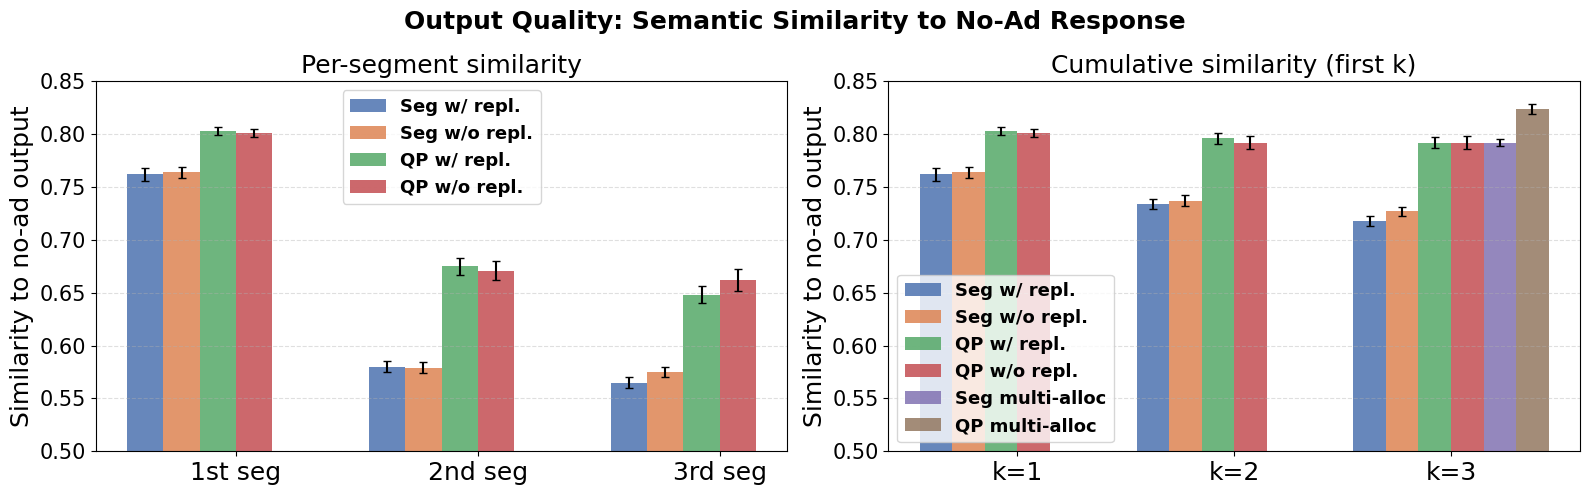

In [36]:
# ── Bar chart ─────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']
COLOR_MAP = {label: color for label, color in zip(results, COLORS)}

bar_w = 0.15
n_m   = len(results)

K3_ORDER = ['Seg w/ repl.', 'Seg w/o repl.',  'QP w/ repl.','QP w/o repl.', 'Seg multi-alloc', 'QP multi-alloc'  ]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))


plt.rcParams.update({
    'font.weight': 'normal',
    'axes.titleweight': 'normal',
    'axes.labelweight': 'normal',
})

# ── Left: per-segment  ────────────────────────────────────────
ax = axes[0]
x = np.arange(len(SEG_KEYS))
for m_idx, (label, color) in enumerate(zip(results, COLORS)):
    means  = [round(results[label][k][0], 3) if results[label][k] is not None else 0 for k in SEG_KEYS]
    errors = [round(results[label][k][1], 3) if results[label][k] is not None else 0 for k in SEG_KEYS]
    valid  = [results[label][k] is not None for k in SEG_KEYS]
    bar_means  = [m if v else np.nan for m, v in zip(means,  valid)]
    bar_errors = [e if v else np.nan for e, v in zip(errors, valid)]
    ax.bar(x + (m_idx - n_m/2 + 0.5)*bar_w, bar_means, bar_w,
           yerr=bar_errors,
           label=label if label not in ('Seg multi-alloc', 'QP multi-alloc') else '_nolegend_',
           color=color, capsize=3, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(['1st seg', '2nd seg', '3rd seg'], fontsize=18)
ax.set_ylabel('Similarity to no-ad output', fontsize=18)
ax.set_title('Per-segment similarity', fontsize=18)
ax.set_ylim(0.5, 0.85)
ax.tick_params(axis='y', labelsize=15)
ax.grid(axis='y', linestyle='--', alpha=0.4)

leg = ax.legend(fontsize=13, loc='upper center')
for text in leg.get_texts():
    text.set_fontweight('bold')


# ── Right: cumulative ───────────────────────────────────
ax = axes[1]
x = np.arange(len(CUM_KEYS))
for m_idx, label in enumerate(K3_ORDER):
    color = COLOR_MAP[label]
    for k_idx, k in enumerate(CUM_KEYS):
        val = results[label][k]
        if k == 'k3':
            pos = m_idx
        else:
            pos = list(results.keys()).index(label)
        mean_val  = round(val[0], 3) if val is not None else np.nan
        error_val = round(val[1], 3) if val is not None else np.nan
        ax.bar(k_idx + (pos - n_m/2 + 0.5)*bar_w, mean_val, bar_w,
               yerr=error_val if not np.isnan(mean_val) else 0,
               color=color, capsize=3, alpha=0.85,
               label=label if k_idx == 0 else '_nolegend_')

ax.set_xticks(x); ax.set_xticklabels(['k=1', 'k=2', 'k=3'], fontsize=18)
ax.tick_params(axis='y', labelsize=15)
ax.set_ylabel('Similarity to no-ad output', fontsize=18)
ax.set_title('Cumulative similarity (first k)', fontsize=18)
ax.set_ylim(0.5, 0.85)
ax.grid(axis='y', linestyle='--', alpha=0.4)

leg = ax.legend(fontsize=13)
for text in leg.get_texts():
    text.set_fontweight('bold')

plt.suptitle('Output Quality: Semantic Similarity to No-Ad Response', fontsize=18, fontweight='bold')
plt.tight_layout()
#plt.savefig('output_quality_similarity.pdf', bbox_inches='tight', dpi=150)
plt.show()